# Laboratorio 9 — Etapa 5: Simulación del Álbum Real FIFA 2026
## MM3014 Teoría de Probabilidades · Universidad del Valle de Guatemala

**Integrantes:**
- Diego Andre Calderón Salazar — 241263
- Pedro Julio Caso — 241286

---

## Datos del problema

| Parámetro | Valor |
|-----------|-------|
| Total de estampas distintas | $N = 980$ |
| Estampas por sobre | $S = 7$ |
| Precio sobre individual | Q 9.50 |
| Precio caja (104 sobres) | Q 975.00 |
| Semilla | 2026 |
| Simulaciones | $R = 3{,}000$ |

---

## Preguntas formuladas

| # | Pregunta | Temática |
|---|----------|----------|
| 1 | ¿Cuál es la probabilidad de completar el álbum comprando exactamente 2 cajas (208 sobres) sin intercambio? | Probabilidad de éxito con cantidad fija de sobres / comparación cajas |
| 2 | ¿Cuál es la probabilidad de completar el álbum con exactamente 140 sobres usando intercambio con $K = 1$? | Efecto del intercambio + escenario extremo |
| 3 | Con 156 sobres totales (equivalente a caja y media), ¿hay diferencia en el número esperado de repetidas entre comprarlo todo en cajas (1 caja + 52 sueltos) versus 156 sobres sueltos? | Comparación sueltos vs. cajas + estampas repetidas |
| 4 | ¿Cuál es la probabilidad de completar el álbum con un presupuesto de Q1,700 sin intercambio? | Probabilidad de éxito con presupuesto fijo |
| 5 | Partiendo de un álbum al 75% completo (735 estampas), si se compran 30 sobres adicionales sin intercambio, ¿cuál es la probabilidad de alcanzar al menos el 95% (≥ 931 estampas)? | Escenario extremo / progreso incremental |

## Importaciones y parámetros globales

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import math

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

N              = 980
S              = 7
PRECIO_SOBRE   = 9.50
PRECIO_CAJA    = 975.00
SOBRES_POR_CAJA = 104

R    = 3_000
SEED = 2026

rng = np.random.default_rng(SEED)

---
## Pregunta 1
### ¿Cuál es la probabilidad de completar el álbum comprando exactamente 2 cajas (208 sobres) sin intercambio?

**Contexto:**  
Dos cajas Panini contienen $2 \times 104 = 208$ sobres, lo que equivale a un gasto de $2 \times \text{Q}975 = \text{Q}1{,}950$.  
El mínimo teórico sin ninguna repetida es $\lceil 980 / 7 \rceil = 140$ sobres, por lo que 208 sobres representan apenas un 48.6% de margen sobre ese mínimo.  
Sin intercambio, el número esperado de sobres para completar el álbum real es aproximadamente 1,045 (calculado en Etapa 2), por lo que 208 sobres está muy por debajo del valor esperado.

**Hipótesis antes de simular:**  
Se espera que la probabilidad sea muy baja, dado que 208 sobres es apenas ~20% del valor esperado.

**Metodología:**
1. Simular $R$ veces la compra de exactamente 208 sobres (sin restricción de presupuesto ni intercambio).
2. Contar cuántas simulaciones resultan en el álbum completo.
3. Calcular la proporción como estimación de la probabilidad.
4. Visualizar con un diagrama de barras (completó vs. no completó) y reportar también el número promedio de estampas distintas obtenidas cuando no se completa.

In [3]:
# ── Parámetros específicos ──────────────────────────────────────────
SOBRES_P1 = 2 * SOBRES_POR_CAJA   # 208 sobres = 2 cajas
GASTO_P1  = 2 * PRECIO_CAJA       # Q 1,950

# ── Simulación ──────────────────────────────────────────────────────
rng_p1 = np.random.default_rng(SEED)

completado_p1 = np.zeros(R, dtype=bool)
distintas_p1  = np.zeros(R, dtype=int)

for i in range(R):
    album    = np.zeros(N, dtype=bool)
    stickers = rng_p1.integers(0, N, size=SOBRES_P1 * S)
    album[stickers] = True
    distintas_p1[i]  = int(album.sum())
    completado_p1[i] = distintas_p1[i] == N

# ── Resultados ──────────────────────────────────────────────────────
prob_p1          = completado_p1.mean()
no_comp          = ~completado_p1
media_dist_nocomp = distintas_p1[no_comp].mean() if no_comp.any() else float(N)
media_dist_total  = distintas_p1.mean()

print(f'Sobres: {SOBRES_P1}  ({SOBRES_P1 // SOBRES_POR_CAJA} cajas)  |  Gasto: Q{GASTO_P1:,.2f}')
print(f'P(completar álbum)              = {prob_p1:.4f}  ({prob_p1*100:.2f} %)')
print(f'E[distintas totales]            = {media_dist_total:.2f} / {N}  ({media_dist_total/N*100:.2f} %)')
print(f'E[distintas | no completó]      = {media_dist_nocomp:.2f} / {N}  ({media_dist_nocomp/N*100:.2f} %)')
print(f'Simulaciones que completaron    = {completado_p1.sum()} / {R}')


Sobres: 208  (2 cajas)  |  Gasto: Q1,950.00
P(completar álbum)              = 0.0000  (0.00 %)
E[distintas totales]            = 758.49 / 980  (77.40 %)
E[distintas | no completó]      = 758.49 / 980  (77.40 %)
Simulaciones que completaron    = 0 / 3000


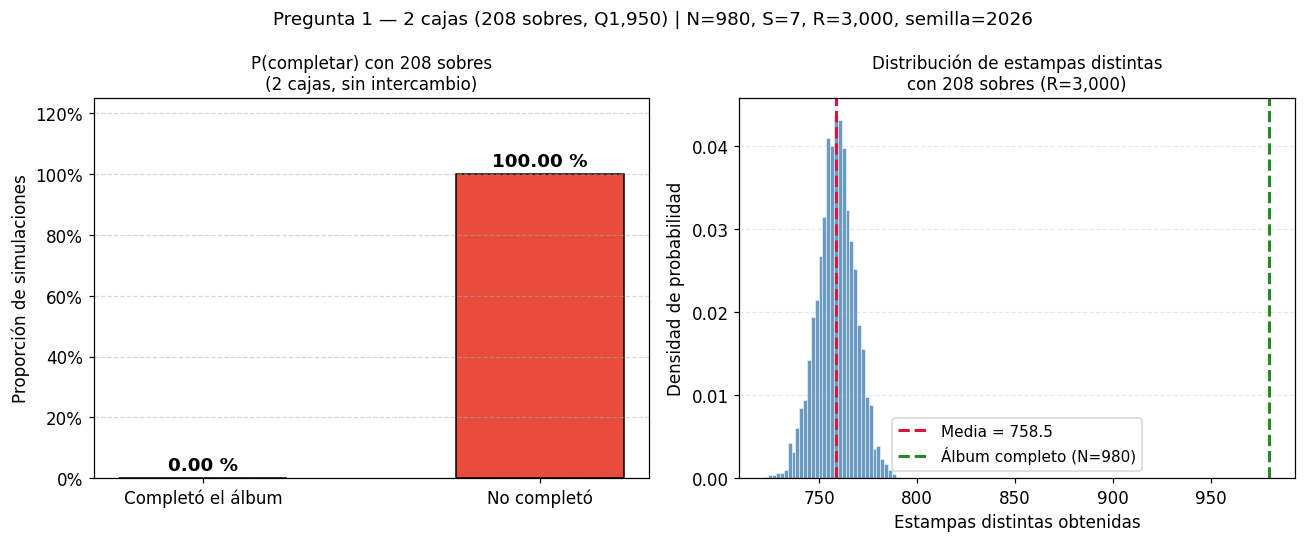

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Izquierda: barras completó vs no completó ────────────────────────
ax1 = axes[0]
etiquetas = ['Completó el álbum', 'No completó']
props     = [prob_p1, 1 - prob_p1]
colores   = ['#2ECC71', '#E74C3C']
bars = ax1.bar(etiquetas, props, color=colores, edgecolor='black', width=0.5)
for bar, p in zip(bars, props):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.012,
             f'{p*100:.2f} %',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.25)
ax1.set_ylabel('Proporción de simulaciones', fontsize=11)
ax1.set_title(f'P(completar) con {SOBRES_P1} sobres\n(2 cajas, sin intercambio)', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# ── Derecha: histograma de estampas distintas ────────────────────────
ax2 = axes[1]
ax2.hist(distintas_p1, bins=35, density=True,
         color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.8)
ax2.axvline(media_dist_total, color='crimson', linestyle='--', linewidth=2,
            label=f'Media = {media_dist_total:.1f}')
ax2.axvline(N, color='forestgreen', linestyle='--', linewidth=2,
            label=f'Álbum completo (N={N})')
ax2.set_xlabel('Estampas distintas obtenidas', fontsize=11)
ax2.set_ylabel('Densidad de probabilidad', fontsize=11)
ax2.set_title(f'Distribución de estampas distintas\ncon {SOBRES_P1} sobres (R={R:,})', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle(
    f'Pregunta 1 — 2 cajas ({SOBRES_P1} sobres, Q{GASTO_P1:,.0f})'
    f' | N={N}, S={S}, R={R:,}, semilla={SEED}',
    fontsize=12
)
plt.tight_layout()
plt.show()


**Análisis y reflexión:**

Como se puede observar en los graficos, comprando 2 cajas sin intercambiar estampas, hay una probabilidad del 0% de completar el album. Usando esta estrategia se podría completar aproximadamente un 77%. Debido a que el precio de cada caja es elevado, no vale la pena intentar completar el album con cajas sin intercambio. 

---
## Pregunta 2
### ¿Cuál es la probabilidad de completar el álbum con exactamente 140 sobres usando intercambio con $K = 1$?

**Contexto:**  
$140 = \lceil 980 / 7 \rceil$ es el **mínimo teórico absoluto** de sobres necesarios para completar el álbum si ninguno tuviera repetidas.  
Con $K = 1$ (cada estampa repetida se puede canjear de inmediato por una nueva), el intercambio es la tasa más favorable posible: cada repetida obtenida se convierte automáticamente en una estampa nueva que falta.  
La pregunta explora si incluso con el intercambio perfecto ($K = 1$) existe alguna probabilidad de completar el álbum en ese mínimo absoluto de sobres, y si no, cuál es la probabilidad real.

**Hipótesis antes de simular:**  
Con $K = 1$, en la Etapa 4 (N=100) se observó que la media bajaba al mínimo teórico ($\approx 15$ sobres para N=100). Para N=980 con K=1, se espera que la media sea cercana a 140 sobres, por lo que la probabilidad de completarlo en **exactamente** 140 podría ser apreciable.

**Metodología:**
1. Simular $R$ veces con el mecanismo de intercambio $K = 1$, registrando el número de sobres necesarios para completar el álbum.
2. Calcular $P(\text{sobres} \leq 140)$ (en 140 o menos) y $P(\text{sobres} = 140)$ (exactamente 140).
3. Visualizar la distribución del número de sobres con un histograma y marcar el umbral de 140.

**Análisis y reflexión:**

> *(Interpretar: ¿qué pasa en el caso K=1 cuando se agota el pool de repetidas disponibles para canjear? ¿Se puede realmente llegar a 140 sobres o hay un límite práctico?)*

---
## Pregunta 3
### Con 156 sobres totales (una caja y media), ¿hay diferencia en el número esperado de repetidas entre comprarlos como caja + sueltos versus 156 sobres todos sueltos?

**Contexto:**  
"Caja y media" equivale a 156 sobres totales. Las dos estrategias de compra son:
- **Estrategia A — Caja + sueltos:** 1 caja (104 sobres, Q975) + 52 sobres sueltos (Q494) = 156 sobres, gasto total Q1,469.
- **Estrategia B — Todo sueltos:** 156 sobres individuales × Q9.50 = 156 sobres, gasto total Q1,482.

Ambas estrategias resultan en exactamente 156 sobres abiertos. Dado que en la simulación cada sobre es independiente (S=7 estampas aleatorias de N=980 con reposición), se espera que la **distribución de repetidas sea estadísticamente indistinguible** entre ambas estrategias.  
La pregunta busca confirmar (o refutar) esto experimentalmente, y adicionalmente comparar el **costo** de cada estrategia.

**Hipótesis antes de simular:**  
Las distribuciones de repetidas deberían ser prácticamente idénticas dado que el mecanismo de generación de estampas es el mismo en ambos casos. La única diferencia real es el costo total (Q1,469 vs Q1,482).

**Metodología:**
1. Simular $R$ veces la apertura de exactamente 156 sobres en ambas estrategias, registrando el número de repetidas.
2. Calcular medias, desviaciones estándar y comparar las distribuciones.
3. Visualizar con histogramas superpuestos y un boxplot comparativo.
4. Reportar el ahorro/diferencia de costo entre estrategias.

**Análisis y reflexión:**

> *(Interpretar: ¿se confirma o refuta la hipótesis? ¿Qué criterio debería usar el coleccionista para decidir entre estrategias si las repetidas son iguales?)*

---
## Pregunta 4
### ¿Cuál es la probabilidad de completar el álbum con un presupuesto de Q1,700 sin intercambio?

**Contexto:**  
Con Q1,700 las opciones de compra son:
- **Solo sueltos:** $\lfloor 1700 / 9.50 \rfloor = 178$ sobres (gasto Q1,691, vuelto Q9).
- **1 caja + sueltos:** 1 caja (Q975) + $\lfloor 725 / 9.50 \rfloor = 76$ sueltos = 180 sobres (gasto Q1,697, vuelto Q3).
- **Solo cajas:** $\lfloor 1700 / 975 \rfloor = 1$ caja = 104 sobres (gasto Q975, vuelto Q725 — muy ineficiente).

En la Etapa 2 se estableció que con Q1,000 se obtenían ~94% de probabilidad para N=100. Para N=980, Q1,700 (~178–180 sobres) representa apenas ~17% del valor esperado de sobres (~1,045), por lo que se espera una probabilidad muy baja.

**Hipótesis antes de simular:**  
La probabilidad será muy pequeña (probablemente < 1%), ya que 180 sobres está muy lejos del valor esperado de 1,045.

**Metodología:**
1. Para cada estrategia de compra (sueltos y mixta), determinar el número máximo de sobres comprables con Q1,700.
2. Simular $R$ veces para cada estrategia, comprando hasta ese límite de sobres.
3. Calcular la probabilidad de completar el álbum y el número esperado de estampas distintas en los casos no exitosos.
4. Visualizar comparativamente con barras y reportar el porcentaje promedio del álbum completado al agotar el presupuesto.

**Análisis y reflexión:**

> *(Interpretar: ¿qué porcentaje del álbum se completa en promedio con Q1,700? ¿Qué dice esto sobre el costo real del álbum real vs. el álbum reducido de N=100?)*

---
## Pregunta 5
### Partiendo de un álbum al 75% (735 estampas ya obtenidas), si se compran 30 sobres adicionales sin intercambio, ¿cuál es la probabilidad de alcanzar al menos el 95% del álbum (≥ 931 estampas)?

**Contexto:**  
Suponer que un coleccionista ya tiene exactamente el 75% del álbum completo:
$$0.75 \times 980 = 735 \text{ estampas distintas ya obtenidas}$$
Le quedan 245 estampas por conseguir. Compra 30 sobres adicionales ($30 \times 7 = 210$ estampas brutas, gasto Q285). Para alcanzar el 95% necesita:
$$\lceil 0.95 \times 980 \rceil = 931 \text{ estampas distintas}$$
Es decir, necesita obtener **196 estampas nuevas** en esos 30 sobres. Esto implica que de las 210 estampas brutas, al menos 196 deben ser nuevas (máximo 14 repetidas, tasa de éxito de nuevas > 93%).

Dado que aún faltan 245 estampas de 980, la probabilidad de que cada estampa sea nueva al momento de abrir el sobre es relativamente alta al principio pero decrece a medida que se acercan al 95%.

**Hipótesis antes de simular:**  
La probabilidad será moderada pero no alta: partir del 75% deja un margen de estampas faltantes razonable (245), pero lograr 196 nuevas en solo 210 intentos es restrictivo.

**Metodología:**
1. Para cada simulación, generar un estado inicial de 735 estampas distintas elegidas aleatoriamente de las 980.
2. Simular la apertura de 30 sobres adicionales (210 estampas) sin intercambio.
3. Verificar si al final se tienen ≥ 931 estampas distintas.
4. Calcular la probabilidad como proporción de simulaciones exitosas.
5. Visualizar la distribución del porcentaje del álbum alcanzado tras los 30 sobres, marcando el umbral del 95%.

**Análisis y reflexión:**

> *(Interpretar: ¿cuántas estampas nuevas se obtienen en promedio con esos 30 sobres? ¿Qué tan eficiente es comprar sobres cuando ya se tiene el 75% del álbum?)*

---
## Conclusiones

### Resumen de resultados

| # | Pregunta | Resultado principal |
|---|----------|---------------------|
| 1 | P(completar con 2 cajas, 208 sobres, sin intercambio) | *(completar)* |
| 2 | P(completar con exactamente 140 sobres, K=1) | *(completar)* |
| 3 | Diferencia en repetidas: caja+sueltos vs todo sueltos (156 sobres) | *(completar)* |
| 4 | P(completar con Q1,700 sin intercambio) | *(completar)* |
| 5 | P(pasar de 75% a ≥95% con 30 sobres, sin intercambio) | *(completar)* |

### Reflexión final

> *(Escribir aquí una reflexión de 3-5 oraciones sobre los hallazgos más interesantes o sorprendentes del laboratorio. ¿Qué aprendieron sobre el problema del coleccionista con estos escenarios?)*